In [5]:
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
import sklearn.preprocessing
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
import math
# from google.colab import drive
# drive.mount('/content/drive')

    # For DeepLIFT, Integrated Gradients
# !pip install captum -q
# from captum.attr import DeepLift, IntegratedGradients, GradientShap, DeepLiftShap

In [6]:
# Choose whether you want to run LSTM or Transformer
ARCHITECTURE = 'LSTM'
MODEL_PATH = f'../models/{ARCHITECTURE}_10epochs_final.pth'

# ARCHITECTURE = 'Transformer'
# MODEL_PATH = f'../models/{ARCHITECTURE}_13epochs_final.pth'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FORECAST_HORIZON = 28
N_STEPS = 22
number_of_features = 21
feature_cols = [
    'units_sold',
    'item_id', 'store_id', 'item_category', 'sell_price', 'consumer_sentiment',
    'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'state_snap',
    'state_cpi', 'state_ur', 'state_gas_price',
    'state_cpi_mom_delta', 'state_ur_mom_delta', 'state_gas_wow_delta',
    'day_of_week', 'day_of_month', 'month', 'year'
]
units_col = feature_cols.index('units_sold')

dataset_file = 'dataset_final.pqt'
# from google.colab import drive
# drive.mount('/content/drive')
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/Master training')
df = pd.read_parquet(f'../data/{dataset_file}')


with open('../data/encoders.json') as f:
    encoders = json.load(f)


In [7]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout
        )
        # self.fc = nn.Linear(hidden_size, 1)
        self.fc = nn.Linear(hidden_size, FORECAST_HORIZON)

    def forward(self, x):
        device = DEVICE
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.to(device)

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Transformer(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, dropout):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        self._causal_mask = None

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc = nn.Linear(d_model, FORECAST_HORIZON)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.input_projection.weight)
        nn.init.zeros_(self.fc.bias)
        nn.init.uniform_(self.fc.weight, -0.1, 0.1)

    def _get_causal_mask(self, seq_len, device):
        if self._causal_mask is None or self._causal_mask.size(0) != seq_len:
            mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
            self._causal_mask = mask.masked_fill(mask == 1, float('-inf'))
        return self._causal_mask

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        causal_mask = self._get_causal_mask(x.size(1), x.device)
        x = self.transformer_encoder(x, mask=causal_mask)

        x = self.fc(x[:, -1, :])
        return x

In [9]:
train_mask = ~(
    ((df['year'] == 2016) & (df['month'] == 4) & (df['day_of_month'] >= 25)) |
    ((df['year'] == 2016) & (df['month'] == 5))
)
df_train = df[train_mask]

lookback_mask = (
    ((df['year'] == 2016) & (df['month'] == 4) & (df['day_of_month'] >= 3)) |
    ((df['year'] == 2016) & (df['month'] == 5))
)
df_eval = df[lookback_mask]

scaler = sklearn.preprocessing.MinMaxScaler()
scaler.fit(df_train[feature_cols].values)
units_col = feature_cols.index('units_sold')


if ARCHITECTURE == 'LSTM':
    model = LSTM(input_size=number_of_features, hidden_size=256, num_layers=2, dropout=0.1).to(DEVICE)
else:
    model = Transformer(input_size=21, d_model=192, nhead=8, num_layers=2, dropout=0.1).to(DEVICE)

trained_model = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(trained_model['model_state_dict'])
model.eval()

C:\Users\juliub\AppData\Local\Temp\ipykernel_39712\3882899924.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_model = torch.load(MODEL_PATH, map_location=DEVICE

LSTM(
  (lstm): LSTM(21, 256, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=256, out_features=28, bias=True)
)

In [10]:
seed_windows = []
actual_windows = []
group_keys = []

for (item_id, store_id), group_df in tqdm(df_eval.groupby(['item_id', 'store_id'], sort=True)):
    group_df = group_df.sort_values(['year', 'month', 'day_of_month'])
    group_scaled = scaler.transform(group_df[feature_cols].values).astype(np.float32)

    seed_windows.append(group_scaled[:FORECAST_HORIZON])
    actual_windows.append(group_scaled[FORECAST_HORIZON:FORECAST_HORIZON + N_STEPS, units_col])
    group_keys.append((item_id, store_id))


seed_windows   = np.stack(seed_windows,   axis=0).astype(np.float32)
actual_windows = np.stack(actual_windows, axis=0).astype(np.float32)
n_groups = len(group_keys)


def forecast_all_batched(model, seed_windows_np, device):
    window = torch.from_numpy(seed_windows_np).to(device)
    model.eval()
    with torch.no_grad():
        output = model(window)
    return output.cpu().numpy()

all_preds_scaled = forecast_all_batched(model, seed_windows, DEVICE)
all_preds_scaled = all_preds_scaled[:, :N_STEPS]


def inv_transform_batch(values_2d, units_col, n_features, scaler):
    n_groups, n_steps = values_2d.shape
    flat  = values_2d.flatten()
    dummy = np.zeros((len(flat), n_features), dtype=np.float32)
    dummy[:, units_col] = flat
    inv   = scaler.inverse_transform(dummy)[:, units_col]
    return inv.reshape(n_groups, n_steps)

all_preds_inv = inv_transform_batch(all_preds_scaled, units_col, number_of_features, scaler)
all_actuals_inv = inv_transform_batch(actual_windows, units_col, number_of_features, scaler)

100%|██████████| 30490/30490 [00:30<00:00, 1013.64it/s]



LSTM metrics: 
MAE: 1.0489 units
RMSE: 2.1799 units
MAPE: 57.92%
SMAPE: 139.94%
Bias: -0.12 units


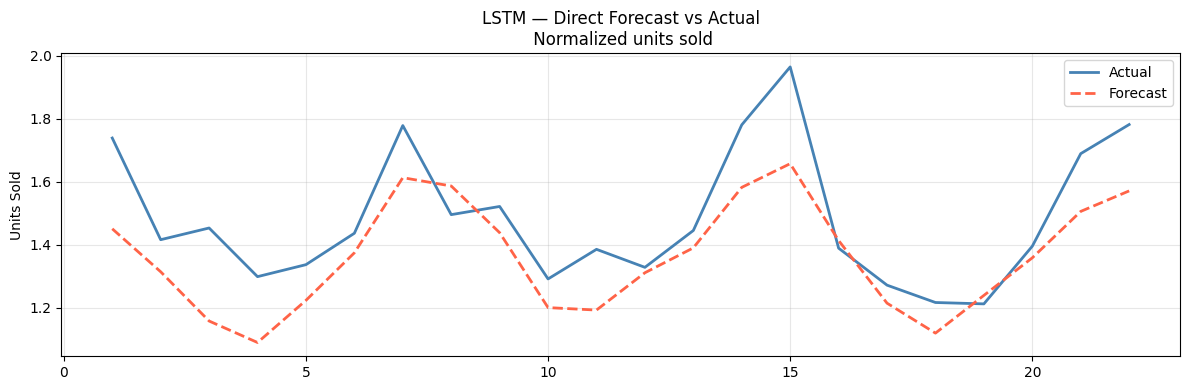

In [11]:
    # Metrics - MAE, RMSE, MAPE, SMAPE, Bias
flat_preds = all_preds_inv.flatten()
flat_actuals = all_actuals_inv.flatten()
nonzero_mask = flat_actuals > 0

mae = np.mean(np.abs(flat_preds - flat_actuals))
rmse = np.sqrt(np.mean((flat_preds - flat_actuals) ** 2))
mape = np.mean(np.abs((flat_preds[nonzero_mask] - flat_actuals[nonzero_mask]) / flat_actuals[nonzero_mask])) * 100
smape = np.mean(2 * np.abs(flat_preds - flat_actuals) / (np.abs(flat_preds) + np.abs(flat_actuals) + 1e-8)) * 100
bias = np.mean(flat_preds - flat_actuals)

print(f"\n{ARCHITECTURE} metrics: ")
print(f"MAE: {mae:.4f} units")
print(f"RMSE: {rmse:.4f} units")
print(f"MAPE: {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"Bias: {bias:.2f} units")


mean_preds = all_preds_inv.mean(axis=0)
mean_actuals = all_actuals_inv.mean(axis=0)
days = np.arange(1, N_STEPS + 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days, mean_actuals, label='Actual',   linewidth=2, color='steelblue')
ax.plot(days, mean_preds,   label='Forecast', linewidth=2, color='tomato', linestyle='--')
ax.set_title(f'{ARCHITECTURE} — Direct Forecast vs Actual\n Normalized units sold')
ax.set_ylabel('Units Sold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

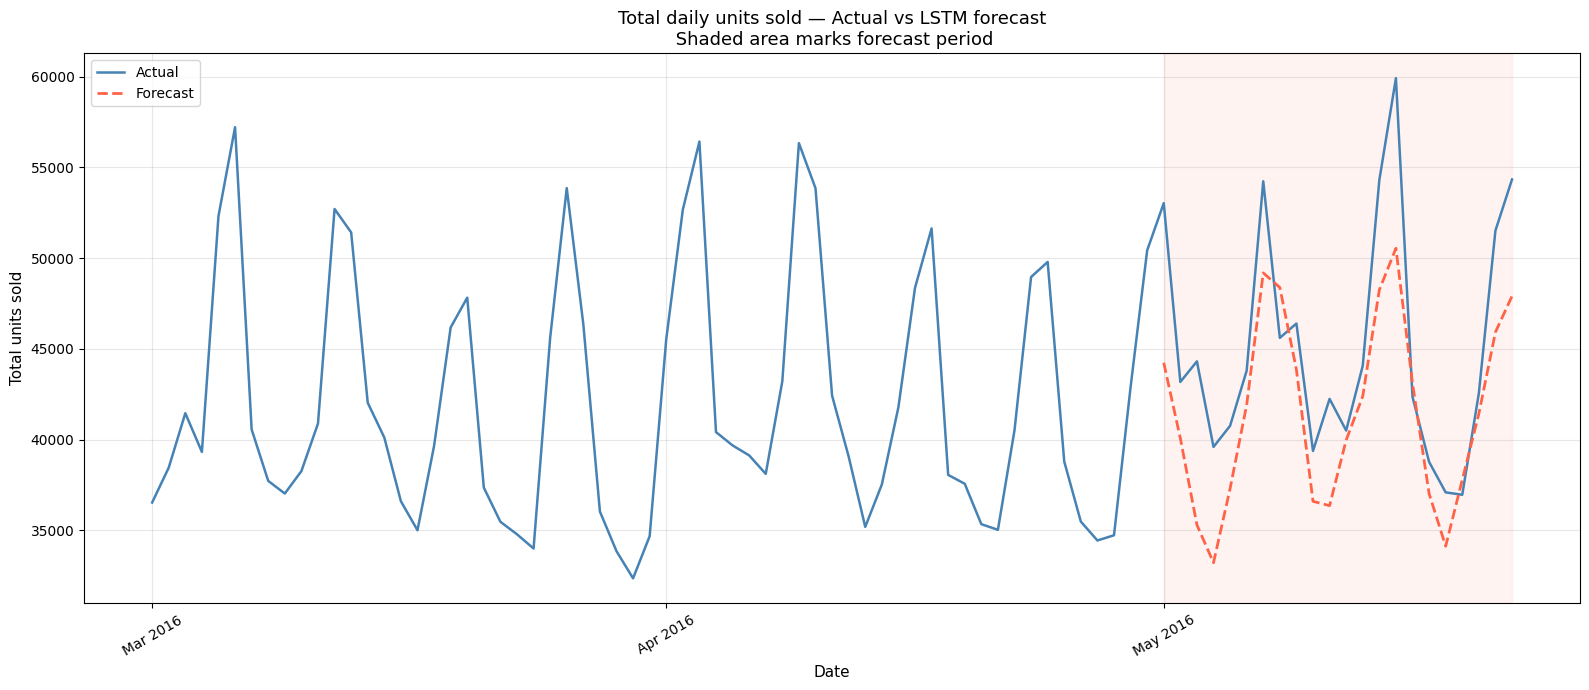

In [12]:
df_2016 = df[df['year'] == 2016].copy()
df_2016 = df_2016[df_2016['month'] >= 3]
df_2016['date'] = pd.to_datetime({
    'year':  df_2016['year'],
    'month': df_2016['month'],
    'day':   df_2016['day_of_month'] })

daily_2016_sales = (
    df_2016
    .groupby('date')['units_sold']
    .sum()
    .sort_index()
    .reset_index())
daily_2016_sales.columns = ['date', 'total_units']

all_preds_scaled = forecast_all_batched(model, seed_windows, DEVICE)
all_preds_scaled = all_preds_scaled[:, :N_STEPS]
all_preds_inv = inv_transform_batch(all_preds_scaled, units_col, number_of_features, scaler)

daily_forecast_total = all_preds_inv.sum(axis=0)
forecast_dates = pd.date_range('2016-05-01', periods=N_STEPS, freq='D')

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(daily_2016_sales['date'], daily_2016_sales['total_units'], color='steelblue', linewidth=1.8, label='Actual', zorder=2 )

ax.plot(forecast_dates, daily_forecast_total, color='tomato', linewidth=2, linestyle='--', label='Forecast', zorder=3 )

ax.axvspan( pd.Timestamp('2016-05-01'), forecast_dates[-1], alpha=0.07, color='tomato', zorder=0)

ax.set_title(f'Total daily units sold — Actual vs {ARCHITECTURE} forecast\n Shaded area marks forecast period', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total units sold', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print(all_preds_inv.max())
print(all_actuals_inv.max())

144.27734
187.0


In [16]:
time_horizons = {
    '1st Day': slice(0, 1),
    '1st Week (1-7d)': slice(0, 7),
    '1st and 2nd Weeks':   slice(0, 14),
    'Monthly (28-day)': slice(0, 22),
}

results = {}

for horizon_name, horizon_slice in time_horizons.items():
    p = all_preds_inv[:, horizon_slice].flatten()
    a = all_actuals_inv[:, horizon_slice].flatten()
    nonzero_mask = a > 0

    mae   = np.mean(np.abs(p - a))
    rmse  = np.sqrt(np.mean((p - a) ** 2))
    mape  = np.mean(np.abs((p[nonzero_mask] - a[nonzero_mask]) / a[nonzero_mask])) * 100
    smape = np.mean(2 * np.abs(p - a) / (np.abs(p) + np.abs(a) + 1e-8)) * 100
    bias  = np.mean(p - a)

    results[horizon_name] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'SMAPE': smape, 'Bias': bias}


    print(f"\n{ARCHITECTURE} — {horizon_name}")
    print(f"Mean units sold: {np.mean(np.abs(a))}")
    print(f"MAE: {mae:.4f} units")
    print(f"RMSE: {rmse:.4f} units")
    print(f"MAPE: {mape:.2f}%")
    print(f"SMAPE: {smape:.2f}%")
    print(f"Bias: {bias:.4f} units")


# Summary
print(f"\n{'Horizon':<20} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'SMAPE':>8} {'Bias':>8}")
print("-" * 60)
for horizon_name, m in results.items():
    print(f"{horizon_name:<20} {m['MAE']:>8.4f} {m['RMSE']:>8.4f} {m['MAPE']:>7.2f}% {m['SMAPE']:>7.2f}% {m['Bias']:>8.4f}")


LSTM — 1st Day
Mean units sold: 1.7393243312835693
MAE: 1.0974 units
RMSE: 2.1242 units
MAPE: 57.34%
SMAPE: 135.27%
Bias: -0.2884 units

LSTM — 1st Week (1-7d)
Mean units sold: 1.494330644607544
MAE: 1.0238 units
RMSE: 2.1659 units
MAPE: 58.71%
SMAPE: 141.51%
Bias: -0.1766 units

LSTM — 1st and 2nd Weeks
Mean units sold: 1.4793024063110352
MAE: 1.0374 units
RMSE: 2.1779 units
MAPE: 58.65%
SMAPE: 141.05%
Bias: -0.1274 units

LSTM — Monthly (28-day)
Mean units sold: 1.483320951461792
MAE: 1.0489 units
RMSE: 2.1799 units
MAPE: 57.92%
SMAPE: 139.94%
Bias: -0.1194 units

Horizon                   MAE     RMSE     MAPE    SMAPE     Bias
------------------------------------------------------------
1st Day                1.0974   2.1242   57.34%  135.27%  -0.2884
1st Week (1-7d)        1.0238   2.1659   58.71%  141.51%  -0.1766
1st and 2nd Weeks      1.0374   2.1779   58.65%  141.05%  -0.1274
Monthly (28-day)       1.0489   2.1799   57.92%  139.94%  -0.1194


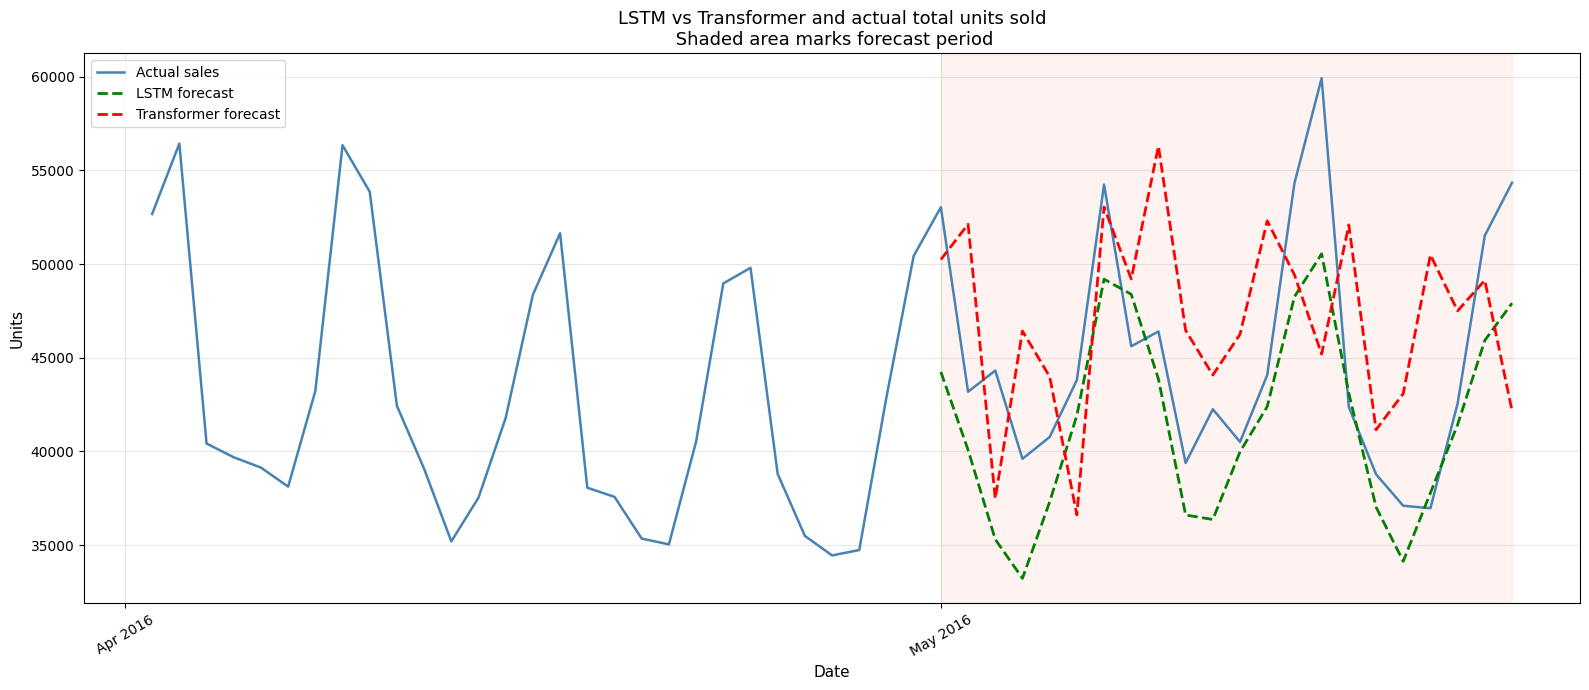

In [17]:
# Retrieved manually to plot both on same plot
lstm_daily_sold = [44238.016, 40075.02,  35302.28,  33221.35,  37303.74,  41911.324, 49189.242,
    48383.824, 43859.418, 36601.75,  36363.49,  39978.62,  42390.55,  48251.84,
    50546.01,  43102.605, 37032.016, 34129.652, 37784.527, 41425.125, 45922.086, 47908.84]

trans_daily_sold = [50235.438, 52121.77,  37474.945, 46423.05,  43986.953, 36611.22,  53038.766,
    49204.125, 56290.254, 46455.055, 44073.176, 46252.824, 52303.273, 49423.914,
    45190.465, 52089.29,  41152.426, 43080.57,  50488.086, 47498.035, 49131.664, 42173.117]


daily_2016_sales = daily_2016_sales[daily_2016_sales['date'] > '2016-04-01']

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(daily_2016_sales['date'], daily_2016_sales['total_units'], color='steelblue', linewidth=1.8, label='Actual sales', zorder=2 )

ax.plot(forecast_dates, lstm_daily_sold, color='green', linewidth=2, linestyle='--', label='LSTM forecast', zorder=3 )

ax.plot(forecast_dates, trans_daily_sold, color='red', linewidth=2, linestyle='--', label='Transformer forecast', zorder=3 )

ax.axvspan( pd.Timestamp('2016-05-01'), forecast_dates[-1], alpha=0.07, color='tomato', zorder=0)

ax.set_title(f'LSTM vs Transformer and actual total units sold\n Shaded area marks forecast period', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Units', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()